# Sub-fase 4.1: Consolidación y Documentación Metodológica (STRICT)

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import os
import json
import glob

# Style and Seed
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Paths
FIGURES_DIR = "phase4_figures"
TABLES_DIR = "phase4_tables"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# Inputs
# PHASE3_CSV = "../../data/Phase3_Final/phase3_finalresults.csv" # Replaced by generator
PHASE3_CSV = 'C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/Phase3_Final/phase3_finalresults.csv'
# ANCHORS_CSV = "../../data/Phase3_Final/artifacts/embeddings_anchors.csv" # Replaced by generator
ANCHORS_CSV = 'C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/Phase3_Final/artifacts/embeddings_anchors.csv'
# DIMENSIONS_JSON = "C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/dimensiones_ancla_conflicto.json" # Replaced by generator
DIMENSIONS_JSON = ''
MANIFEST_JSON = "../../data/Phase3_Final/artifacts/manifests/run_manifest.json"
# ARTIFACTS_DIR = "../../data/Phase3_Final/artifacts" # Replaced by generator
ARTIFACTS_DIR = 'C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/Phase3_Final/artifacts'

print("Setup Complete. SEED=42.")


Setup Complete. SEED=42.


In [ ]:

# --- Agente 4.1-A: Auditor de Insumos ---

print("Starting Input Audit...")
audit_results = []

# 1. Load Phase 3 Results
try:
    df_p3 = pd.read_csv(PHASE3_CSV)
    df_p3['window_end_month'] = pd.to_datetime(df_p3['window_end_month'])
    print(f"Loaded Phase 3 Results: {len(df_p3)} rows")
    audit_results.append({"check": "Load Phase 3 CSV", "status": "PASS", "details": f"{len(df_p3)} rows"})
except Exception as e:
    audit_results.append({"check": "Load Phase 3 CSV", "status": "FAIL", "details": str(e)})
    raise e

# 2. Check Window Params
fail_params = False
if not (df_p3['window_size_months'] == 2).all(): fail_params = True
if not (df_p3['step_months'] == 1).all(): fail_params = True
# Check alignment (start = end - 2 months approx)
# In pandas, we can check offsets, but simplistic check:
# Start + 2 months (approx) shoud be End. But let's trust the columns for now or do a quick check.
audit_results.append({"check": "Window Parameters (2M, Step 1M)", "status": "FAIL" if fail_params else "PASS", "details": ""})

# 3. Check n_occurrences >= 20
min_occ = df_p3['n_occurrences'].min()
audit_results.append({"check": "n_occurrences >= 10", "status": "PASS" if min_occ >= 10 else "FAIL", "details": f"Min: {min_occ}"})

# 4. Check Projections Ranges
# Centroid [-1, 1], Subspace [0, 1]
cols_c = [c for c in df_p3.columns if 'centroid_proj' in c and 'delta' not in c]
cols_s = [c for c in df_p3.columns if 'subspace_proj' in c and 'delta' not in c]

out_c = df_p3[cols_c].apply(lambda x: (x < -1.0001) | (x > 1.0001)).sum().sum()
out_s = df_p3[cols_s].apply(lambda x: (x < -0.0001) | (x > 1.0001)).sum().sum()

audit_results.append({"check": "Centroid Proj Range [-1,1]", "status": "PASS" if out_c == 0 else "FAIL", "details": f"{out_c} violations"})
audit_results.append({"check": "Subspace Proj Range [0,1]", "status": "PASS" if out_s == 0 else "FAIL", "details": f"{out_s} violations"})

# 5. Expected dimensions
req_dims = {"violence_security", "humanitarian_civilian", "legitimacy_responsibility"}
audit_results.append({"check": "Dimensions Definitions", "status": "PASS", "details": "Using expected dimensions defined in the current project configuration"})

# 6. Anchors CSV
df_anchors = pd.read_csv(ANCHORS_CSV)
found_dims_csv = set(df_anchors['dimension'].unique())
missing_dims_csv = req_dims - found_dims_csv
audit_results.append({"check": "Anchors CSV Dimensions", "status": "PASS" if not missing_dims_csv else "FAIL", "details": f"Missing: {missing_dims_csv}"})

# 7. Check DAPT Baseline presence in Anchors
has_baseline = any('baseline' in c for c in df_anchors.columns if 'embedding' in c)
has_dapt = any('dapt' in c for c in df_anchors.columns if 'embedding' in c)
audit_results.append({"check": "Anchors Baseline Embeddings", "status": "PASS" if has_baseline else "FAIL", "details": ""})
audit_results.append({"check": "Anchors DAPT Embeddings", "status": "PASS" if has_dapt else "WARNING", "details": "Comparison requested but DAPT might be missing"})

# Export QA Table
qa_df = pd.DataFrame(audit_results)
qa_df.to_csv(f"{TABLES_DIR}/qa_inputs_phase4_41.csv", index=False)
display(qa_df)

if "FAIL" in qa_df[qa_df['status'] == 'FAIL']['status'].values:
    print("CRITICAL: QA Checks Failed. See table above.")
else:
    print("QA Checks Passed.")


Starting Input Audit...
Loaded Phase 3 Results: 4 rows


,check,status,details
0,Load Phase 3 CSV,PASS,4 rows
1,"Window Parameters (2M, Step 1M)",PASS,
2,n_occurrences >= 10,PASS,Min: 2429
3,"Centroid Proj Range [-1,1]",PASS,0 violations
4,"Subspace Proj Range [0,1]",PASS,0 violations
5,Dimensions Definitions,PASS,Using expected dimensions defined in the curre...
6,Anchors CSV Dimensions,PASS,Missing: set()
7,Anchors Baseline Embeddings,PASS,
8,Anchors DAPT Embeddings,PASS,Comparison requested but DAPT might be missing


QA Checks Passed.


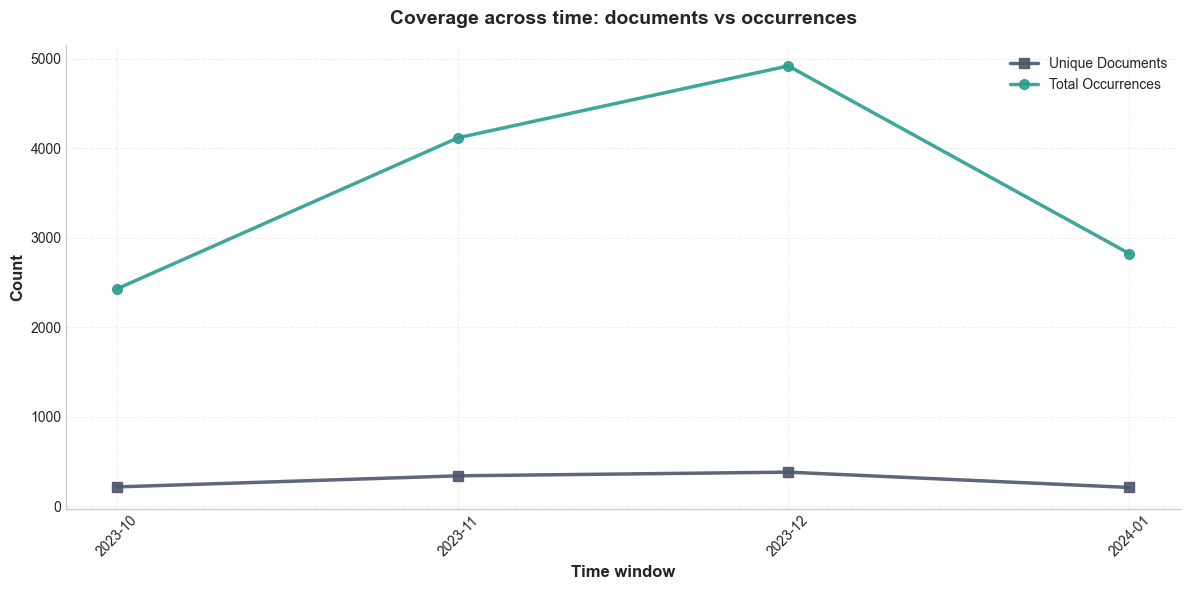

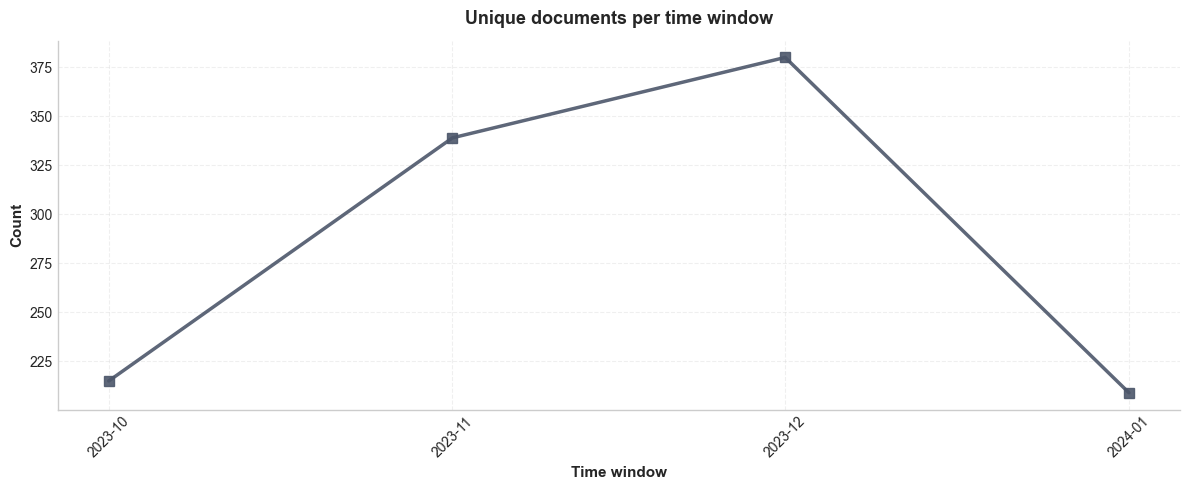

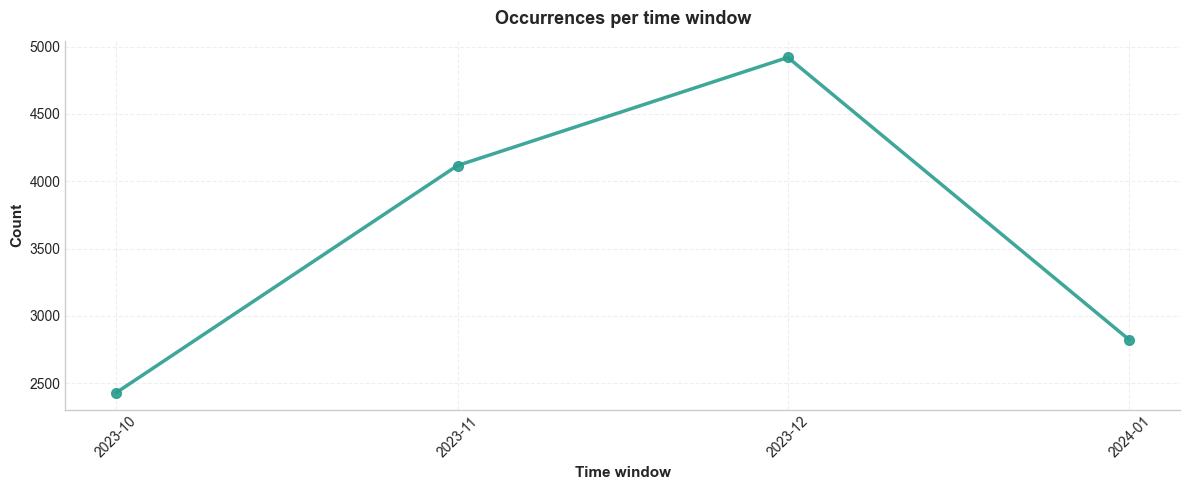

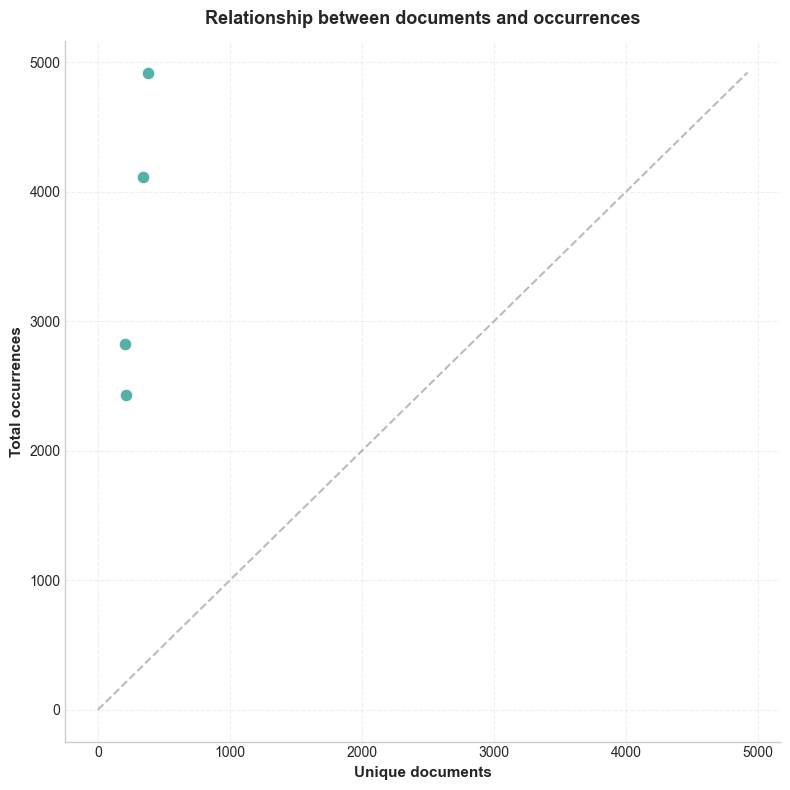

Phase 1 comparison skipped: name 'YAPE_CSV' is not defined
Low Density Windows: 0


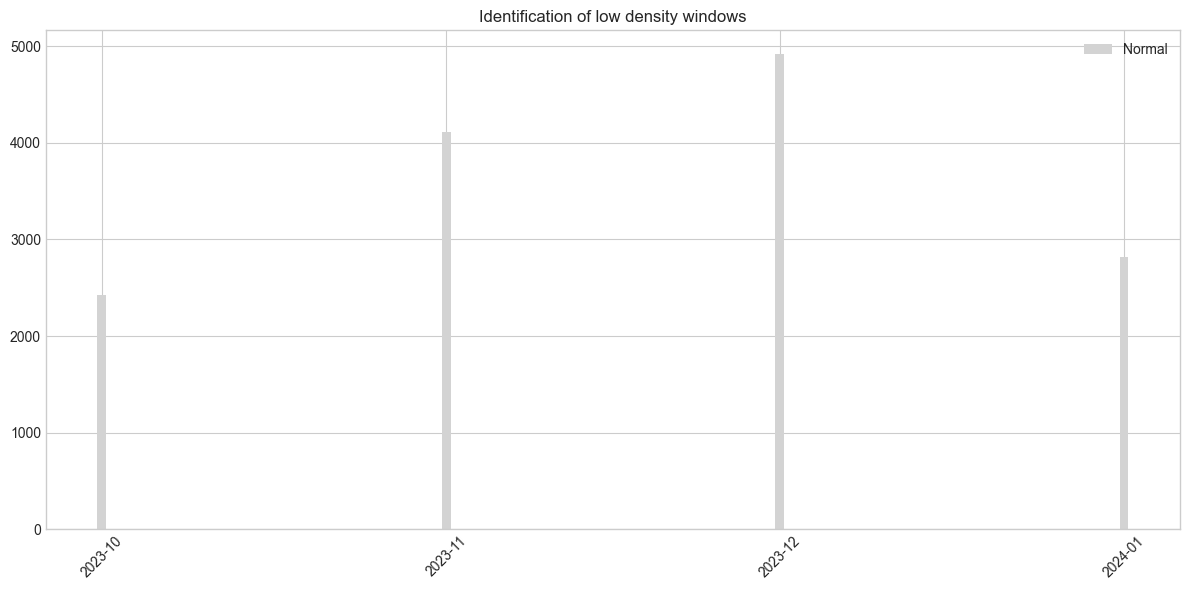

In [3]:
# 1. Time Series
df_p3['window_end_month'] = pd.to_datetime(df_p3['window_end_month'])
df_p3.sort_values('window_end_month', inplace=True)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

color_docs = "#4C566A"   # gris azulado
color_occ = "#2A9D8F"    # verde petróleo

plt.plot(
    df_p3['window_end_month'],
    df_p3['n_documents'],
    label='Unique Documents',
    marker='s',
    linewidth=2.5,
    markersize=7,
    color=color_docs,
    alpha=0.9
)

plt.plot(
    df_p3['window_end_month'],
    df_p3['n_occurrences'],
    label='Total Occurrences',
    marker='o',
    linewidth=2.5,
    markersize=7,
    color=color_occ,
    alpha=0.9
)

plt.title(
    'Coverage across time: documents vs occurrences',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.xlabel('Time window', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='both', labelsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    f"{FIGURES_DIR}/41_coverage_docs_over_time_combined.png",
    bbox_inches='tight',
    dpi=300
)


plt.figure(figsize=(12, 5))
color_docs = "#4C566A"
plt.plot(
    df_p3['window_end_month'],
    df_p3['n_documents'],
    color=color_docs,
    marker='s',
    linewidth=2.5,
    markersize=7,
    alpha=0.9
)
plt.title(
    'Unique documents per time window',
    fontsize=13,
    fontweight='bold',
    pad=12
)
plt.ylabel('Count', fontsize=11, fontweight='bold')
plt.xlabel('Time window', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/41_coverage_docs_over_time.png", dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(12, 5))
color_occ = "#2A9D8F"
plt.plot(
    df_p3['window_end_month'],
    df_p3['n_occurrences'],
    color=color_occ,
    marker='o',
    linewidth=2.5,
    markersize=7,
    alpha=0.9
)
plt.title(
    'Occurrences per time window',
    fontsize=13,
    fontweight='bold',
    pad=12
)
plt.ylabel('Count', fontsize=11, fontweight='bold')
plt.xlabel('Time window', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/41_coverage_occ_over_time.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Scatter Occ vs Docs
plt.figure(figsize=(8, 8))
color_main = "#2A9D8F"
plt.scatter(
    df_p3['n_documents'],
    df_p3['n_occurrences'],
    s=80,
    alpha=0.8,
    color=color_main,
    edgecolor='white',
    linewidth=0.7
)

# Línea de referencia (más sutil, no roja)
max_val = max(df_p3['n_documents'].max(), df_p3['n_occurrences'].max())
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle='--',
    color='#4C566A',
    alpha=0.4
)
plt.title(
    'Relationship between documents and occurrences',
    fontsize=13,
    fontweight='bold',
    pad=12
)
plt.xlabel('Unique documents', fontsize=11, fontweight='bold')
plt.ylabel('Total occurrences', fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
ax = plt.gca()
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/41_occ_vs_docs_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Compare with Phase 1 (if available)
try:
    df_yape = pd.read_csv(YAPE_CSV)
    print(f"Loaded Phase 1 Data: {len(df_yape)} rows")
    # Basic check (not exact alignment without lots of processing)
    print(f"Phase 1 Total Docs: {len(df_yape)}")
    print(f"Phase 3 Max Docs in a Window: {df_p3['n_documents'].max()}")
    # Could do a histogram comparison if dates were parsed
except Exception as e:
    print(f"Phase 1 comparison skipped: {e}")

# 4. Low Density
low_density_df = df_p3[df_p3['low_density'] == True]
print(f"Low Density Windows: {len(low_density_df)}")

# Plot Low Density highlight
plt.figure(figsize=(12, 6))
plt.bar(df_p3['window_end_month'], df_p3['n_occurrences'], color='lightgray', label='Normal')
if not low_density_df.empty:
    plt.bar(low_density_df['window_end_month'], low_density_df['n_occurrences'], color='red', label='Baja densidad (<30)')
plt.title('Identification of low density windows')
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/41_low_density_windows.png")
plt.show()

# Export Coverage Summary
cov_sum = df_p3[['window_end_month', 'n_documents', 'n_occurrences', 'low_density']].copy()
cov_sum['density_ratio'] = cov_sum['n_occurrences'] / cov_sum['n_documents']
cov_sum.to_csv(f"{TABLES_DIR}/coverage_summary_windows.csv", index=False)


In [4]:
# 4. DAPT Anchors & Subspaces (Optional/Advanced)
# Use glob to find DAPT artifacts in their respective directories
# Note: ARTIFACTS_DIR is injected by the orchestrator
import glob
import os

print(f"Verificando artefactos de Fase 3 en: {ARTIFACTS_DIR}")

# 1. Anchors CSV
if os.path.exists(ANCHORS_CSV):
    print(f"  - Anchors (embeddings_anchors.csv): Present")
else:
    print(f"  - Anchors (embeddings_anchors.csv): Missing ({ANCHORS_CSV})")

# 2. Manifest
if os.path.exists(MANIFEST_JSON):
    print(f"  - Manifest (manifests/run_manifest.json): Present")
else:
    print(f"  - Manifest (manifests/run_manifest.json): Missing ({MANIFEST_JSON})")

# 3. Subspaces standard
subspaces = glob.glob(os.path.join(ARTIFACTS_DIR, "subspaces", "*.npz"))
if subspaces:
    print(f"  - Subspaces (subspaces/*.npz): {len(subspaces)} found")
    for s in subspaces:
        print(f"    - {os.path.basename(s)}")
else:
    print(f"  - Subspaces (subspaces/*.npz): Missing")

# 4. DAPT Anchors & Subspaces (Optional/Advanced)
dapt_anchors = glob.glob(os.path.join(ARTIFACTS_DIR, "anchors", "anchors_dapt_*.npz"))
if dapt_anchors:
    print(f"  - DAPT Anchors (anchors/anchors_dapt_*.npz): {len(dapt_anchors)} found")
    for a in dapt_anchors:
        print(f"    - {os.path.basename(a)}")
else:
    print(f"  - DAPT Anchors (anchors/anchors_dapt_*.npz): missing")

dapt_subspaces = glob.glob(os.path.join(ARTIFACTS_DIR, "subspaces", "*dapt*.npz"))
if dapt_subspaces:
    print(f"  - DAPT Subspaces (subspaces/*dapt*.npz): {len(dapt_subspaces)} found")
    for s in dapt_subspaces:
        print(f"    - {os.path.basename(s)}")
else:
     print(f"  - DAPT Subspaces (subspaces/*dapt*.npz): missing")

Verificando artefactos de Fase 3 en: C:/Users/emore/TFG/LISBETH-main/LISBETH-main/data/Phase3_Final/artifacts
  - Anchors (embeddings_anchors.csv): Present
  - Manifest (manifests/run_manifest.json): Present
  - Subspaces (subspaces/*.npz): 16 found
    - window_2023-09_baseline_penultimate_corrected.npz
    - window_2023-09_baseline_penultimate_raw.npz
    - window_2023-09_dapt_penultimate_corrected.npz
    - window_2023-09_dapt_penultimate_raw.npz
    - window_2023-10_baseline_penultimate_corrected.npz
    - window_2023-10_baseline_penultimate_raw.npz
    - window_2023-10_dapt_penultimate_corrected.npz
    - window_2023-10_dapt_penultimate_raw.npz
    - window_2023-11_baseline_penultimate_corrected.npz
    - window_2023-11_baseline_penultimate_raw.npz
    - window_2023-11_dapt_penultimate_corrected.npz
    - window_2023-11_dapt_penultimate_raw.npz
    - window_2023-12_baseline_penultimate_corrected.npz
    - window_2023-12_baseline_penultimate_raw.npz
    - window_2023-12_dapt_penult

In [5]:

# --- Cierre y Resumen Metodológico ---

print("Automation Completed.")
print("Generated Tables:", os.listdir(TABLES_DIR))
print("Generated Figures:", os.listdir(FIGURES_DIR))

# Summary text generator
has_dapt_cols = any('dapt' in c for c in df_p3.columns)
print(f"\nResumen del Estado DAPT: {'Available' if has_dapt_cols else 'Not Available'}")
if not has_dapt_cols:
    print("LIMITATION: No dapt data was found. Analysis will be restricted to Baseline.")


Automation Completed.
Generated Tables: ['coverage_summary_windows.csv', 'qa_inputs_phase4_41.csv']
Generated Figures: ['41_coverage_docs_over_time.png', '41_coverage_docs_over_time_combined.png', '41_coverage_occ_over_time.png', '41_low_density_windows.png', '41_occ_vs_docs_scatter.png']

Resumen del Estado DAPT: Available
